# Exploratory Data Analysis

Goal: Identify features influencing property close price

- Author: Johnny Lin
- Last Revision: 01/31/2026

First, we read in and combine the last 6 months of data on houses and filter by residential, single-family homes. 

In [55]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

In [56]:
# READ, COMBINE, AND FILTER DATA

csv_files = glob.glob("../data/raw/*.csv")

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

filtered_df = combined_df[
    (combined_df["PropertyType"]=="Residential") &
    (combined_df["PropertySubType"]=="SingleFamilyResidence")
]

print("Shape (rows x columns): ", filtered_df.shape)
filtered_df.head()

filtered_df.set_index("ListingId",inplace=True)


C:\Users\jzlin\AppData\Local\Temp\ipykernel_10476\2200924308.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


Shape (rows x columns):  (78948, 78)


Next, we perform several sanity checks:

In [57]:


columns = dfs[0].columns.tolist()
same = True
for i, df in enumerate(dfs[1:]):
    if columns != df.columns.tolist():
        same = False
print("Are all column headers the same? ", same)


Are all column headers the same?  True


In [58]:
print("Number of duplicates: ", filtered_df.duplicated().sum())

Number of duplicates:  5


Not a lot of duplicates --> not an immediate problem

In [59]:
# Check basic structure
filtered_df.info()
filtered_df.describe(include='all').T


<class 'pandas.core.frame.DataFrame'>
Index: 78948 entries, EV21134678 to IG20153137
Data columns (total 77 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuyerAgentAOR                 78936 non-null  object 
 1   ListAgentAOR                  78936 non-null  object 
 2   Flooring                      51269 non-null  object 
 3   ViewYN                        71561 non-null  object 
 4   WaterfrontYN                  34 non-null     object 
 5   BasementYN                    1926 non-null   object 
 6   PoolPrivateYN                 72888 non-null  object 
 7   OriginalListPrice             78790 non-null  float64
 8   ListingKey                    78948 non-null  int64  
 9   ListAgentEmail                78689 non-null  object 
 10  CloseDate                     78948 non-null  object 
 11  ClosePrice                    78948 non-null  float64
 12  ListAgentFirstName            78400 non-null  objec

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BuyerAgentAOR,78936,52,OrangeCounty,5794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ListAgentAOR,78936,52,OrangeCounty,5794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flooring,51269,242,"Carpet,Tile",5448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ViewYN,71561,2,True,43850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WaterfrontYN,34,1,True,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
HighSchoolDistrict,57823,402,Los Angeles Unified,4688,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PostalCode,78947,1758,92253,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AssociationFee,"55,874",NaN,NaN,NaN,102,319,0,0,0,126,"15,750"
LotSizeSquareFeet,"77,637",NaN,NaN,NaN,"415,451","17,636,180",0,"5,663","7,295","10,454","1,938,942,720"


In [60]:
filtered_df.isna().sum().to_frame("missing_count").T


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
missing_count,12,12,27679,7387,78914,77022,6060,158,0,259,...,73883,1301,30667,5990,3199,21125,1,23074,1311,78948


We are tasked with predicting the close price of homes. Then ClosePrice is the column of interest.

In [61]:
from matplotlib import *

pd.options.display.float_format = '{:,.0f}'.format

filtered_df['ClosePrice'].describe(include='all')


count        78,948
mean      1,330,030
std       8,427,929
min               0
25%         625,000
50%         885,000
75%       1,400,000
max     989,500,000
Name: ClosePrice, dtype: float64

Split into training and test, then trim top and bottom 0.5% close prices.

In [62]:
filtered_df = filtered_df.copy()
date_columns = [c for c in filtered_df.columns if c[-4:] == "Date"]

In [63]:

for col in date_columns:
    filtered_df[col] = pd.to_datetime(filtered_df[col])

# Borrowing from Huiyu's code to split training and test data by most recent closing month and trim off by quantiles:
filtered_df["close_month"] = filtered_df["CloseDate"].dt.to_period("M").astype(str).str.replace("-", "").astype("Int64")

test_month = int(filtered_df["close_month"].max())  # last month in CloseDate
print("Test month = ", test_month)

train_data = filtered_df[filtered_df["close_month"] != test_month]
test_data = filtered_df[filtered_df["close_month"] == test_month]

def trim_closeprice(d: pd.DataFrame, lower_q=0.005, upper_q=0.995):
    low = d["ClosePrice"].quantile(lower_q)
    high = d["ClosePrice"].quantile(upper_q)

    d_trim = d[(d["ClosePrice"] >= low) & (d["ClosePrice"] <= high)].copy()

    return d_trim

train_data = trim_closeprice(train_data)
test_data = trim_closeprice(test_data)

train_data["ClosePrice"].describe(include="all")



Test month =  202512


count      67,817
mean    1,190,862
std       957,487
min       190,000
25%       630,000
50%       890,000
75%     1,400,000
max     8,750,000
Name: ClosePrice, dtype: float64

In [64]:
test_data["ClosePrice"].describe(include="all")

count      10,350
mean    1,137,377
std       929,840
min       179,000
25%       610,000
50%       860,000
75%     1,320,000
max     8,550,000
Name: ClosePrice, dtype: float64

In [65]:
# Categorical
categorical_cols = train_data.select_dtypes(include=["object"]).columns
train_data[categorical_cols].describe(include="all").T


,count,unique,top,freq
BuyerAgentAOR,67806,52,OrangeCounty,4986
ListAgentAOR,67806,52,OrangeCounty,4986
Flooring,44217,233,"Carpet,Tile",4724
ViewYN,61318,2,True,37501
WaterfrontYN,26,1,True,26
BasementYN,1626,1,True,1626
PoolPrivateYN,62634,2,False,52173
ListAgentEmail,67586,31507,sold@myattrealestate.com,172
ListAgentFirstName,67333,7481,Michael,849
ListAgentLastName,67809,16835,Smith,316


Descriptions that may not be inherently obvious.

- `BuyerAgentAOR`: The Buyer's Agent's Board or Association of REALTORS
- `ListAgentAOR`: The Listing Agent's Board or Association of REALTORS.
- `Flooring`: A list of the type(s) of flooring found within the property.


Over 95% of values for `WaterfrontYN` and `BasementYN` are missing, so we will very likely drop these features. For the rest of these columns, we may try to impute missing data.

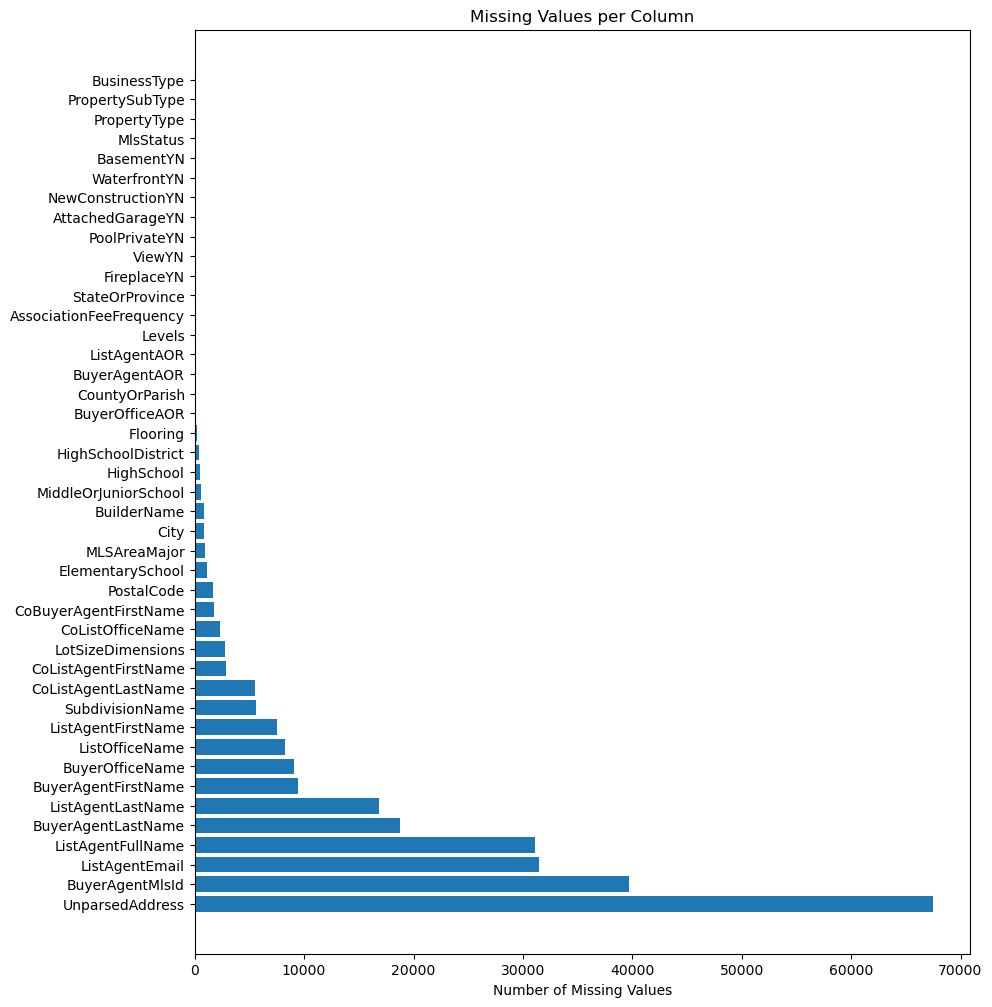

In [66]:
# Analysis of unique counts

unique_counts = train_data[categorical_cols].nunique()
unique_counts = unique_counts.sort_values(ascending=False)

plt.figure(figsize=(10, 12))
plt.barh(unique_counts.index, unique_counts.values)
plt.xlabel("Number of Missing Values")
plt.title("Missing Values per Column")
plt.show()

Several categorical features exhibit very high cardinality (>100 unique values), including agent identifiers and address fields. These variables are unsuitable for one-hot encoding and may introduce sparsity and overfitting. These features will likely be removed or transformed prior to modeling.

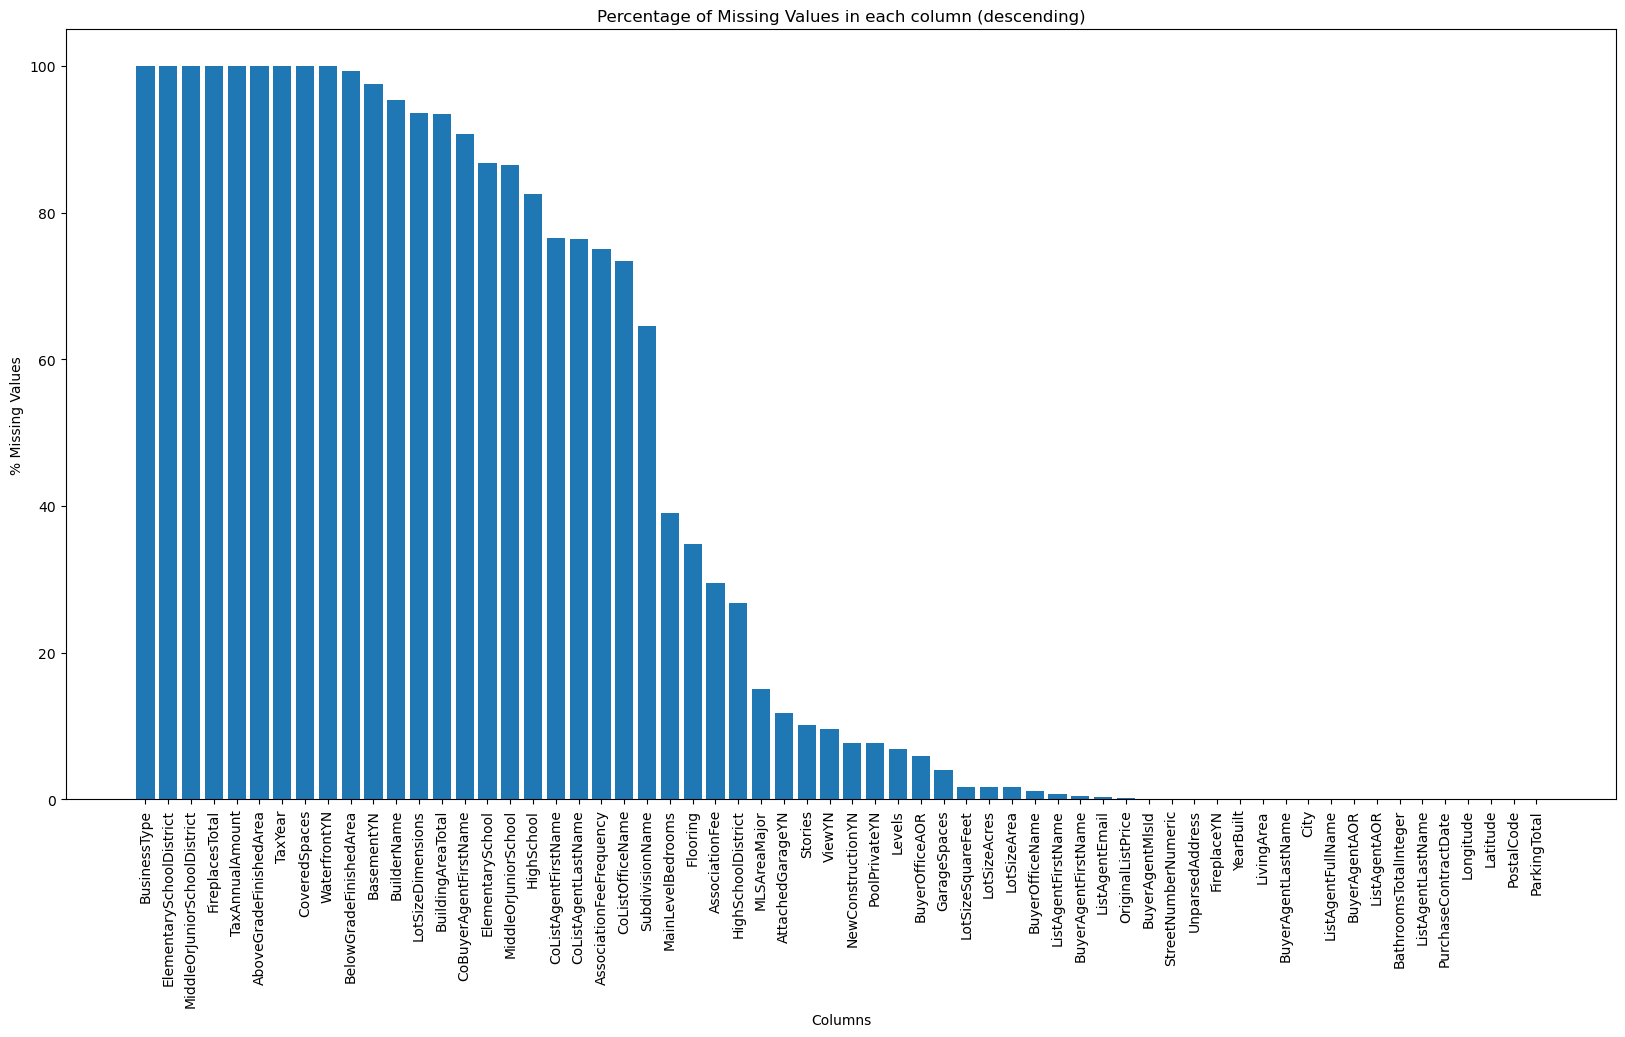

In [67]:
import matplotlib.pyplot as plt

missing_percentages = train_data.isna().mean().sort_values(ascending=False) * 100
missing_percentages = missing_percentages[missing_percentages > 0]

plt.figure(figsize = (20,10))
plt.bar(x=missing_percentages.index, height=missing_percentages)
plt.xticks(rotation=90)
plt.xlabel('Columns')
plt.ylabel('% Missing Values')
plt.title('Percentage of Missing Values in each column (descending)')
plt.show()

### My EDA: Examining the high missing-percentage columns

Obviously, without data, there would be no way to draw insightful conclusions on anything. For that reason, we would generally want to drop columns with high missingness (say, over 50%).

Missingness causes problems: How can we run models like linear regression if they cannot accept missing values? This dataset is so vast that simply dropping any rows with missing values may leave us with too little workable data. But then how should we impute in each column?

I will do some EDA columns with high missingness, just in case there is some way they could still be useful to our models.

In [91]:
high_missing_columns = missing_percentages[(missing_percentages > 30) & (missing_percentages < 100)].index
high_missing_columns

Index(['WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'BuilderName',
       'LotSizeDimensions', 'BuildingAreaTotal', 'CoBuyerAgentFirstName',
       'ElementarySchool', 'MiddleOrJuniorSchool', 'HighSchool',
       'CoListAgentFirstName', 'CoListAgentLastName',
       'AssociationFeeFrequency', 'CoListOfficeName', 'SubdivisionName',
       'MainLevelBedrooms', 'Flooring'],
      dtype='object')

# Column Summary & Missingness Analysis (50-99% Missing)

| Column Name | Summary | Analysis |
|-------------|---------|--------------------------------|
| **WaterfrontYN** | Whether property is on waterfront. | Field is only populated when True, therefore impute missing as False |
| **BelowGradeFinishedArea** | Finished area below ground level (basement). | Tied to BasmentYN which already has high missingness. |
| **BasementYN** | Whether property has a basement. | Only Trues, can imput missing as False |
| **BuilderName** | Name of property builder. | For practical and ethical reasons, we wouldn't want to use individual names. |
| **LotSizeDimensions** | Text description of lot dimensions (e.g., "250 x 180"). | LotSizeAcres is already given and fine to replace this column  |
| **BuildingAreaTotal** | Total building area including finished/unfinished space. | We already have LotSizeAcres |
| **CoBuyerAgentFirstName** | First name of co-buyer's agent. | Individual names = don't use |
| **ElementarySchool** | Name of nearest elementary school. | Agents may not have found this necessary, but I think it *could* be useful (strength of education could factor into price) |
| **MiddleOrJuniorSchool** | Name of nearest middle/junior school. | Same as ElementarySchool |
| **HighSchool** | Name of nearest high school. | Same as above |
| **CoListAgentFirstName** | First name of co-listing agent. | No individual names |
| **CoListAgentLastName** | Last name of co-listing agent. | No individual names |
| **AssociationFeeFrequency** | Frequency of HOA fee payments (Monthly, Annually, etc.). | Only relevant for properties with an HOA; many single-family homes and rural properties lack HOAs. |
| **CoListOfficeName** | Name of co-listing brokerage. | Also uncommon for single-family homes |
| **SubdivisionName** | Name of subdivision/neighborhood development. | Many properties are not in named subdivisions (rural, custom lots, older urban areas). |

---

### Ideas

I feel comfortable about dropping the "person" "name" columns without further analysis.

We can safely impute `BasementYN` and `WaterfrontYN` missing values with False.

We could impute other missing data as string "None"?

**Agent/Transaction Fields** (`CoBuyerAgentFirstName`, `CoListAgentLastName`, `CoListOfficeName`)
- **Missing indicates solo agent/office involvement**.
- Could be useful as a binary feature: `HasCoAgent`, `HasCoOffice`.

---
  

We now compare the mean Closing price of when values are missing compared to when they're present.

In [69]:
df = train_data.copy()

results = []

for col in high_missing_columns:
    means = df.groupby(df[col].isna())["ClosePrice"].mean()
    
    results.append({
        "Feature": col,
        "Missing": means.get(True, None),
        "Not Missing": means.get(False, None)
    })

missing_df = pd.DataFrame(results)

missing_df["Difference"] = (
    missing_df["Missing"] - missing_df["Not Missing"]
)

missing_df = missing_df.sort_values("Difference")


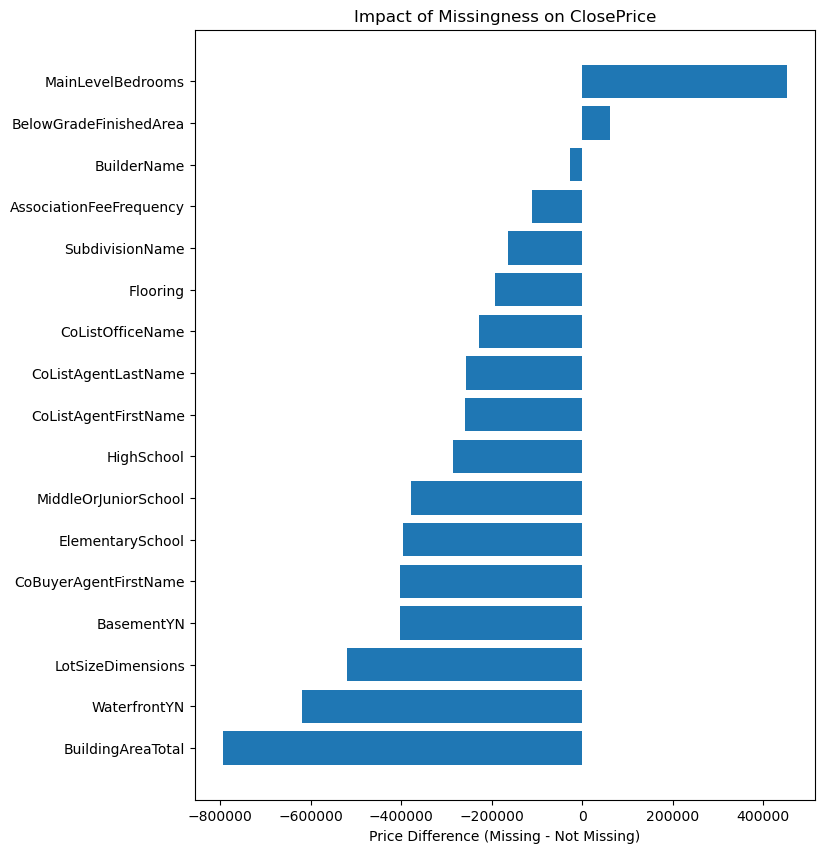

In [70]:
plt.figure(figsize=(8, 10))
plt.barh(missing_df["Feature"], missing_df["Difference"])
plt.xlabel("Price Difference (Missing - Not Missing)")
plt.title("Impact of Missingness on ClosePrice")
plt.show()


In general, when the data is present, the mean closing price is significantly higher. This makes sense for WaterFrontYN and BasementYN, considering that the existence of either suggests a home with more rooms. However, the others perhaps present a bias where the data was only recorded because the listing itself was more luxurious or high-quality.

Interestingly, the presence of `MainLevelBedrooms` correlates negatively with closing price. This may be because luxury homes generally have bedrooms in upper floors and so there would be no main level bedrooms to even consider. Single-story homes may be more likely to fill in this information.

Missingness here is not random and seems to offer its own predictive influence.

In [71]:
for column in high_missing_columns:
    if pd.api.types.is_numeric_dtype(df[column]):
        corr = df[[column, "ClosePrice"]].dropna().corr().iloc[0, 1]
        print(f"{column}: {corr}")

BelowGradeFinishedArea: 0.1608678069251571
BuildingAreaTotal: 0.707016058772239
MainLevelBedrooms: -0.08038577793437021


On top of missingness of the `BuildingAreaTotal` having an effect on close price, there is also strong positive correlation with respect to the few values (around 10%) that are present. I would consider feature engineering a missingness indicator on top of filling the NA rows with the median building area total.

## Final Suggestions

Obviously drop 100% missing columns.

`WaterFrontYN` and `BasementYN` combined are present in ~1% of the data, but still have significant influence. Can be combined as well as `BelowGradeFinishedArea` into `PremiumRoomYN` as a rare but meaningful category.

Combine co-anything related columns and turn into a missing indicator `HasMultipleParties`.

Combine education related columns and turn into missing indicator `HasSchoolData`.

Add missingness indicator `HasBuildingAreaTotal` and `HasMainLevelBedrooms`

Many predictors I expect to be highly correlated with eachother - need to touch base with team to decide which columns to combine, drop, and/or transform.